## Definisikan Masalah :
Superstore ingin memprediksi kapan waktu yang tepat untuk memberikan diskon tanpa merugikan toko. Oleh karena itu, kita akan membangun model dengan dua tujuan utama :

- Memprediksi penjualan di masa depan berdasarkan data historis, sehingga kita bisa tahu kapan penjualan tinggi atau rendah.
- Memprediksi apakah diskon besar akan menguntungkan atau merugikan berdasarkan kondisi penjualan dan produk.

## Langkah 1 : Memahami Struktur data
Di langkah ini, kita akan memuat data dan memeriksa kolom serta beberapa baris pertama dari dataset untuk memahami strukturnya.

In [ ]:
import pandas as pd

# Memuat data dari seluruh sheet
transaction_data = pd.read_excel('/content/Data Superstore - Misi CRISP-DM.xlsx', sheet_name='Transaction')
product_ref_data = pd.read_excel('/content/Data Superstore - Misi CRISP-DM.xlsx', sheet_name='Ref_Product')
region_ref_data = pd.read_excel('/content/Data Superstore - Misi CRISP-DM.xlsx', sheet_name='Ref_Region')
customer_ref_data = pd.read_excel('/content/Data Superstore - Misi CRISP-DM.xlsx', sheet_name='Ref_Customer')
order_ref_data = pd.read_excel('/content/Data Superstore - Misi CRISP-DM.xlsx', sheet_name='Ref_Order')

# Langkah 1: Memeriksa struktur data dari masing-masing sheet
print("Transaction Data Head:")
print(transaction_data.head())

print("\nProduct Reference Data Head:")
print(product_ref_data.head())

print("\nRegion Reference Data Head:")
print(region_ref_data.head())

print("\nCustomer Reference Data Head:")
print(customer_ref_data.head())

print("\nOrder Reference Data Head:")
print(order_ref_data.head())

# Menampilkan informasi tipe data dan jumlah non-null untuk setiap kolom
print("\nTransaction Data Info:")
print(transaction_data.info())

print("\nProduct Reference Data Info:")
print(product_ref_data.info())

print("\nRegion Reference Data Info:")
print(region_ref_data.info())

print("\nCustomer Reference Data Info:")
print(customer_ref_data.info())

print("\nOrder Reference Data Info:")
print(order_ref_data.info())

Transaction Data Head:
         Order ID Customer ID  Postal Code       Product ID     Sales  \
0  CA-2019-152156    CG-12520        42420  FUR-BO-10001798  261.9600   
1  CA-2019-152156    CG-12520        42420  FUR-CH-10000454  731.9400   
2  CA-2019-138688    DV-13045        90036  OFF-LA-10000240   14.6200   
3  US-2018-108966    SO-20335        33311  FUR-TA-10000577  957.5775   
4  US-2018-108966    SO-20335        33311  OFF-ST-10000760   22.3680   

   Quantity  Discount    Profit  
0         2      0.00   41.9136  
1         3      0.00  219.5820  
2         2      0.00    6.8714  
3         5      0.45 -383.0310  
4         2      0.20    2.5164  

Product Reference Data Head:
        Product ID         Category Sub-Category  \
0  FUR-BO-10001798        Furniture    Bookcases   
1  FUR-CH-10000454        Furniture       Chairs   
2  OFF-LA-10000240  Office Supplies       Labels   
3  FUR-TA-10000577        Furniture       Tables   
4  OFF-ST-10000760  Office Supplies      Sto

## Langkah 2 : Menggabungkan data untuk analisis lanjutan
Untuk memanfaatkan seluruh data, kita akan menggabungkan sheet Transaction dengan Ref Product, Ref Region, Ref Customer, dan Ref Order. Ini akan memungkinkan kita untuk menganalisis penjualan berdasarkan kategori produk, wilayah, dan informasi lainnya.

In [ ]:
# Menggabungkan data Transaction dengan Ref Product berdasarkan Product ID
merged_data = pd.merge(transaction_data, product_ref_data, on='Product ID', how='inner')

# Menggabungkan hasil dengan Ref Region berdasarkan Postal Code
merged_data = pd.merge(merged_data, region_ref_data, on='Postal Code', how='inner')

# Menggabungkan hasil dengan Ref Customer berdasarkan Customer ID
merged_data = pd.merge(merged_data, customer_ref_data, on='Customer ID', how='inner')

# Menggabungkan hasil dengan Ref Order berdasarkan Order ID
merged_data = pd.merge(merged_data, order_ref_data, on='Order ID', how='inner')

# Memastikan data telah digabungkan dengan benar
print(merged_data.head())


         Order ID Customer ID  Postal Code       Product ID     Sales  \
0  CA-2019-152156    CG-12520        42420  FUR-BO-10001798  261.9600   
1  CA-2019-152156    CG-12520        42420  FUR-CH-10000454  731.9400   
2  CA-2019-138688    DV-13045        90036  OFF-LA-10000240   14.6200   
3  US-2018-108966    SO-20335        33311  FUR-TA-10000577  957.5775   
4  US-2018-108966    SO-20335        33311  OFF-ST-10000760   22.3680   

   Quantity  Discount    Profit         Category Sub-Category  \
0         2      0.00   41.9136        Furniture    Bookcases   
1         3      0.00  219.5820        Furniture       Chairs   
2         2      0.00    6.8714  Office Supplies       Labels   
3         5      0.45 -383.0310        Furniture       Tables   
4         2      0.20    2.5164  Office Supplies      Storage   

                                        Product Name Country/Region  \
0                  Bush Somerset Collection Bookcase  United States   
1  Hon Deluxe Fabric Upholst

## Langkah 3 : Visualisasi penjualan berdasarkan kategori dan wilayah
Setelah menggabungkan data, kita bisa melanjutkan untuk membuat visualisasi penjualan berdasarkan kategori produk dan wilayah (menggunakan kolom Category dari Ref Product dan Region dari Ref Region).

<ipython-input-10-993b87a71612>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Category', data=category_sales, palette='Blues_d')


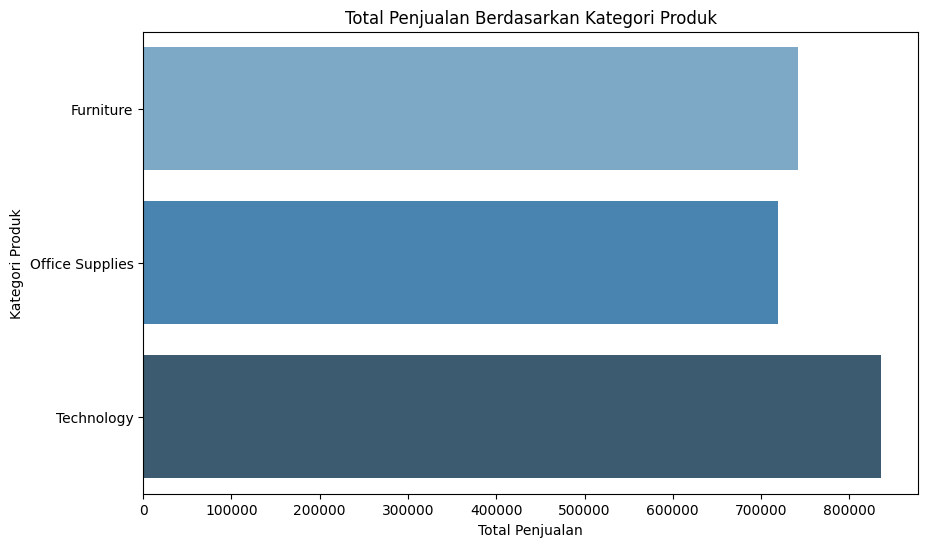

<ipython-input-10-993b87a71612>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Region', data=region_sales, palette='viridis')


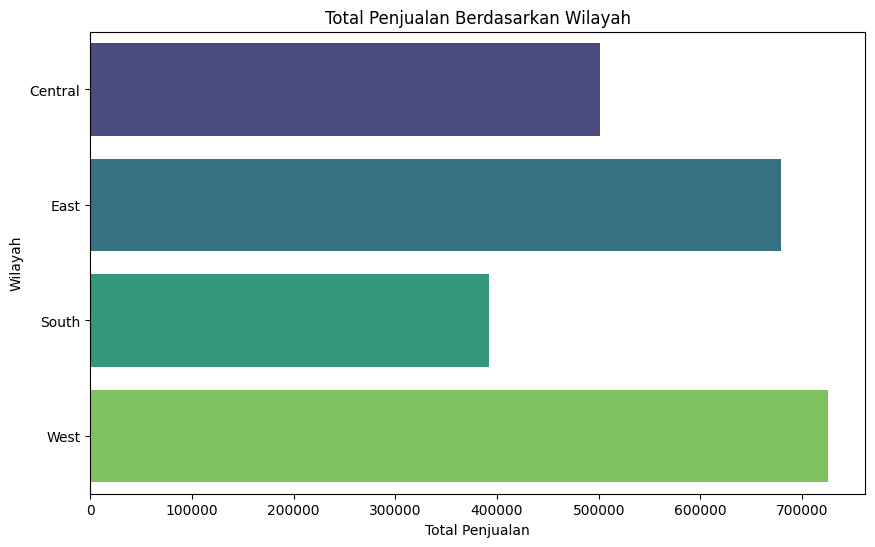

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Langkah 3: Visualisasi Penjualan Berdasarkan Kategori dan Wilayah
# Menghitung total penjualan berdasarkan kategori produk
category_sales = merged_data.groupby('Category')['Sales'].sum().reset_index()

# Visualisasi total penjualan berdasarkan kategori produk
plt.figure(figsize=(10, 6))
sns.barplot(x='Sales', y='Category', data=category_sales, palette='Blues_d')
plt.title('Total Penjualan Berdasarkan Kategori Produk')
plt.xlabel('Total Penjualan')
plt.ylabel('Kategori Produk')
plt.show()

# Menghitung total penjualan berdasarkan wilayah
region_sales = merged_data.groupby('Region')['Sales'].sum().reset_index()

# Visualisasi total penjualan berdasarkan wilayah
plt.figure(figsize=(10, 6))
sns.barplot(x='Sales', y='Region', data=region_sales, palette='viridis')
plt.title('Total Penjualan Berdasarkan Wilayah')
plt.xlabel('Total Penjualan')
plt.ylabel('Wilayah')
plt.show()

Insight :
- Kategori Technology memperolehh penjualan terbanyak dibandingkan kategori lainnya
- Region West memperoleh penjualan terbanyak dibandingkan region lainnya

## Langkah 4 : Prediksi Keberhasilan Diskon dengan Random Forest
Sekarang kita akan melanjutkan dengan menggunakan Random Forest untuk memprediksi apakah diskon besar menguntungkan atau tidak, berdasarkan data yang ada.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Langkah 4: Prediksi Keberhasilan Diskon dengan Random Forest
# Menyiapkan data untuk prediksi diskon
# Asumsikan diskon yang memberikan profit > 0 dianggap menguntungkan
merged_data['Discount_Impact'] = (merged_data['Profit'] > 0).astype(int)

# Fitur yang digunakan untuk model (misalnya Sales, Quantity, Discount, dan Profit)
features = ['Sales', 'Quantity', 'Discount', 'Profit']
X = merged_data[features]
y = merged_data['Discount_Impact']

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat dan melatih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Memprediksi hasil pada data test
y_pred = model_rf.predict(X_test)

# Menampilkan hasil evaluasi model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       377
           1       1.00      1.00      1.00      1622

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999



Insight : Model mampu mengklasifikasikan dengan sangat akurat apakah sebuah diskon menguntungkan atau tidak. Nilai precision, recall, F1-score, dan accuracy yang semuanya 1.00 menunjukkan bahwa model tidak membuat kesalahan dalam memprediksi.

## Langkah 5 : Evaluasi Model dan Interpretasi
Pada langkah ini, kita akan mengevaluasi model yang telah dibuat. Kita juga akan visualisasikan hasil prediksi dibandingkan dengan data yang sebenarnya untuk melihat akurasi model dalam memprediksi keberhasilan diskon.

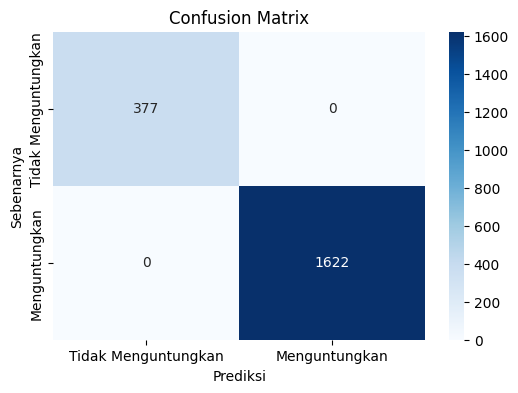

Akurasi Model: 100.00%


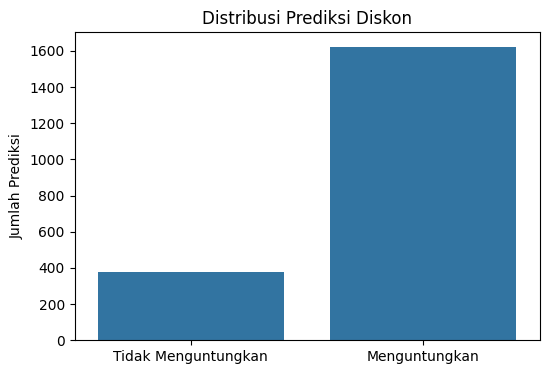

In [ ]:
from sklearn.metrics import confusion_matrix
# Langkah 5: Evaluasi Model dengan Grafik yang Lebih Sederhana
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Menguntungkan', 'Menguntungkan'], yticklabels=['Tidak Menguntungkan', 'Menguntungkan'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.show()

# Menampilkan akurasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")

# Visualisasi distribusi prediksi dan nilai aktual
plt.figure(figsize=(6, 4))
sns.barplot(x=["Tidak Menguntungkan", "Menguntungkan"], y=[cm[0, 0] + cm[0, 1], cm[1, 0] + cm[1, 1]])
plt.title('Distribusi Prediksi Diskon')
plt.ylabel('Jumlah Prediksi')
plt.show()

Insight : Dari grafik ini, kita bisa menyimpulkan bahwa model yang kita gunakan sangat akurat dalam memprediksi apakah sebuah diskon menguntungkan atau tidak. Akurasi model mencapai 100%, artinya model berhasil memprediksi semua data dengan benar.

## Model machine learning yang digunakan adalah **Random Forest Classifier**.

**Alasan pemilihan** :
- **Klasifikasi** : Memungkinkan untuk memprediksi apakah transaksi menguntungkan atau tidak.
- **Robust terhadap overfitting** : Dapat menangani data besar dan kompleks tanpa terlalu menyesuaikan model dengan data pelatihan.
- **Mudah menangani data numerik dan kategorikal** : Cocok dengan data transaksi yang mengandung berbagai tipe variabel (seperti diskon, kategori produk, dll).

Linked In : https://bit.ly/FaizHauzanOnLinkedIn